# 01 — Exploratory Data Analysis

This notebook covers the initial exploration of the **UCI Online Retail II** dataset.

**Goals:**
- Load and merge both year sheets
- Understand data shape, types, and missing values
- Identify and quantify cancellations and returns
- Explore transaction volume over time
- Characterize customer purchase frequency distribution
- Summarize key observations to inform preprocessing decisions in `02_rfm_computation.ipynb`

## 1. Imports & Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 4)})

DATA_PATH = '../data/raw/online_retail_II.xlsx'
FIGURES_PATH = '../reports/figures/'

## 2. Load Data

The dataset consists of two sheets covering December 2009 – December 2011.
We load and concatenate both into a single DataFrame.

In [4]:
print("Loading Year 2009-2010...")
df_0910 = pd.read_excel(DATA_PATH, sheet_name='Year 2009-2010')

print("Loading Year 2010-2011...")
df_1011 = pd.read_excel(DATA_PATH, sheet_name='Year 2010-2011')

df = pd.concat([df_0910, df_1011], ignore_index=True)

print(f"\nCombined shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Loading Year 2009-2010...
Loading Year 2010-2011...

Combined shape: 1,067,371 rows x 8 columns


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


## 3. Schema & Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [6]:
# Rename columns for consistency
df.columns = ['invoice', 'stock_code', 'description', 'quantity',
              'invoice_date', 'price', 'customer_id', 'country']

# Ensure correct dtypes
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['customer_id'] = df['customer_id'].astype('Int64')  # nullable integer

df.dtypes

invoice                 object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
price                  float64
customer_id              Int64
country                 object
dtype: object

## 4. Missing Values

In [7]:
missing = df.isnull().sum().rename('missing_count')
missing_pct = (df.isnull().mean() * 100).rename('missing_pct').round(2)
pd.concat([missing, missing_pct], axis=1)

,missing_count,missing_pct
invoice,0,0.00
stock_code,0,0.00
description,4382,0.41
quantity,0,0.00
invoice_date,0,0.00
price,0,0.00
customer_id,243007,22.77
country,0,0.00


> **Note:** `customer_id` will have a meaningful share of nulls (~25%).
> These rows represent **guest transactions** and must be dropped before RFM computation,
> as they cannot be attributed to a trackable customer.

## 5. Cancellations & Returns

Cancellation invoices are prefixed with `C`. These represent reversed transactions
and must be excluded from purchase history.

In [8]:
df['is_cancellation'] = df['invoice'].astype(str).str.startswith('C')

cancel_count = df['is_cancellation'].sum()
total = len(df)

print(f"Cancellation rows : {cancel_count:,} ({cancel_count/total*100:.1f}%)")
print(f"Normal transaction rows: {total - cancel_count:,} ({(1 - cancel_count/total)*100:.1f}%)")

Cancellation rows : 19,494 (1.8%)
Normal transaction rows: 1,047,877 (98.2%)


In [9]:
# Also check for negative quantities outside of cancellations
neg_qty = df[~df['is_cancellation'] & (df['quantity'] < 0)]
print(f"Non-cancellation rows with negative quantity: {len(neg_qty):,}")

Non-cancellation rows with negative quantity: 3,457


In [10]:
# And zero/negative prices
bad_price = df[df['price'] <= 0]
print(f"Rows with zero or negative price: {len(bad_price):,}")

Rows with zero or negative price: 6,207


## 6. Clean Subset (Preview)

For EDA purposes, we apply basic filters to get a feel for the clean data.
Full preprocessing logic will live in `src/preprocessing.py`.

In [11]:
df_clean = (
    df
    .loc[~df['is_cancellation']]
    .loc[df['quantity'] > 0]
    .loc[df['price'] > 0]
    .dropna(subset=['customer_id'])
    .copy()
)

df_clean['total_price'] = df_clean['quantity'] * df_clean['price']

print(f"Clean rows : {len(df_clean):,}")
print(f"Unique customers: {df_clean['customer_id'].nunique():,}")
print(f"Unique invoices : {df_clean['invoice'].nunique():,}")
print(f"Date range      : {df_clean['invoice_date'].min().date()} → {df_clean['invoice_date'].max().date()}")

Clean rows : 805,549
Unique customers: 5,878
Unique invoices : 36,969
Date range      : 2009-12-01 → 2011-12-09


## 7. Transaction Volume Over Time

Understanding temporal patterns is important for defining the **observation window**
and detecting seasonality that may affect BG/NBD model assumptions.

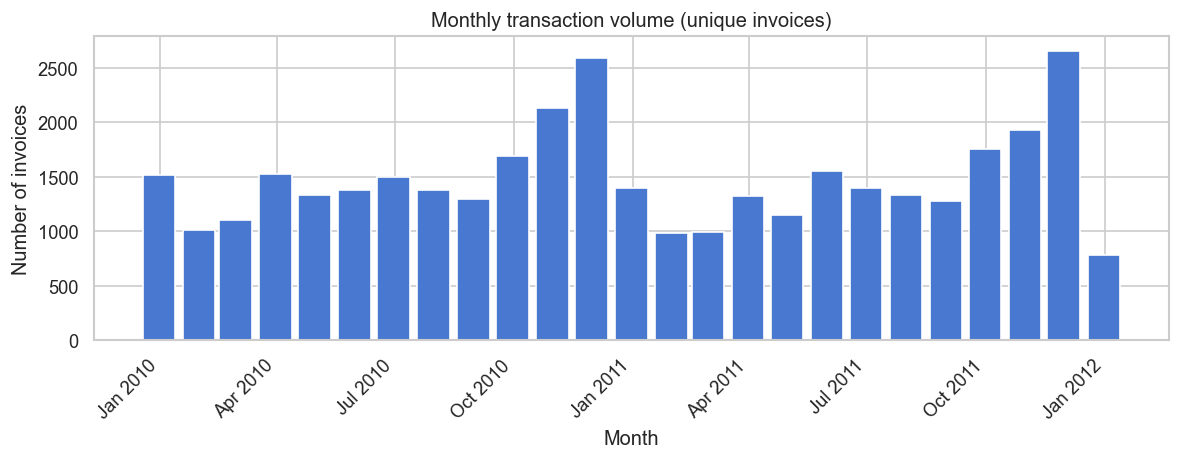

In [14]:
monthly = (
    df_clean
    .set_index('invoice_date')
    .resample('ME')['invoice']
    .nunique()
    .reset_index()
    .rename(columns={'invoice': 'num_invoices', 'invoice_date': 'month'})
)

fig, ax = plt.subplots()
ax.bar(monthly['month'], monthly['num_invoices'], width=25, color=sns.color_palette('muted')[0])
ax.set_title('Monthly transaction volume (unique invoices)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of invoices')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_monthly_volume.png', bbox_inches='tight')
plt.show()

## 8. Monthly Revenue

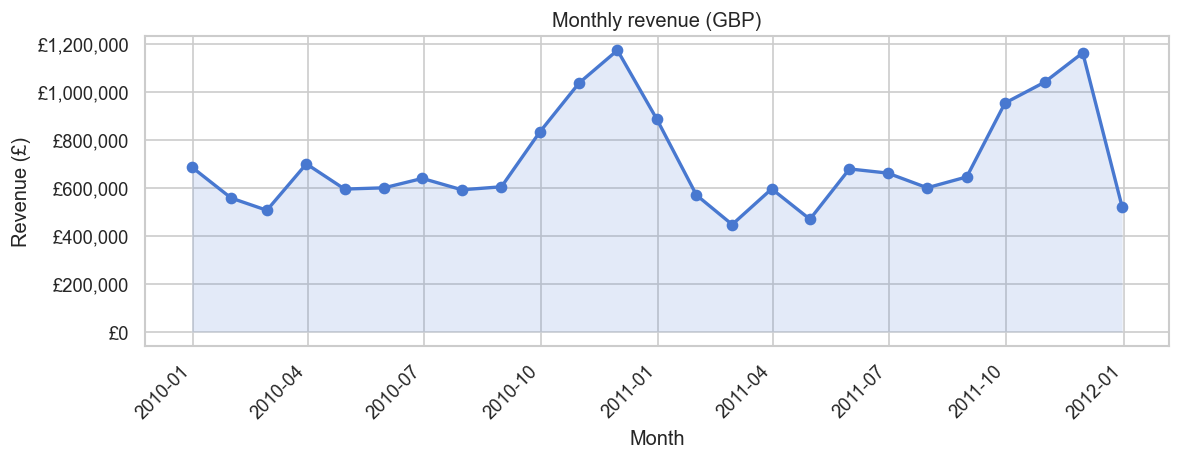

In [15]:
monthly_rev = (
    df_clean
    .set_index('invoice_date')
    .resample('ME')['total_price']
    .sum()
    .reset_index()
    .rename(columns={'total_price': 'revenue', 'invoice_date': 'month'})
)

fig, ax = plt.subplots()
ax.plot(monthly_rev['month'], monthly_rev['revenue'], marker='o', linewidth=2)
ax.fill_between(monthly_rev['month'], monthly_rev['revenue'], alpha=0.15)
ax.set_title('Monthly revenue (GBP)')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_monthly_revenue.png', bbox_inches='tight')
plt.show()

## 9. Customer Purchase Frequency Distribution

This is critical for BG/NBD modeling. The model performs best when there is
sufficient variance in repeat purchase behavior across customers.

In [16]:
customer_freq = (
    df_clean
    .groupby('customer_id')['invoice']
    .nunique()
    .reset_index()
    .rename(columns={'invoice': 'num_invoices'})
)

print("Purchase frequency summary:")
print(customer_freq['num_invoices'].describe().round(2))
print(f"\nCustomers with only 1 purchase : {(customer_freq['num_invoices'] == 1).sum():,} ({(customer_freq['num_invoices'] == 1).mean()*100:.1f}%)")
print(f"Customers with 2+ purchases    : {(customer_freq['num_invoices'] >= 2).sum():,} ({(customer_freq['num_invoices'] >= 2).mean()*100:.1f}%)")

Purchase frequency summary:
count   5878.00
mean       6.29
std       13.01
min        1.00
25%        1.00
50%        3.00
75%        7.00
max      398.00
Name: num_invoices, dtype: float64

Customers with only 1 purchase : 1,623 (27.6%)
Customers with 2+ purchases    : 4,255 (72.4%)


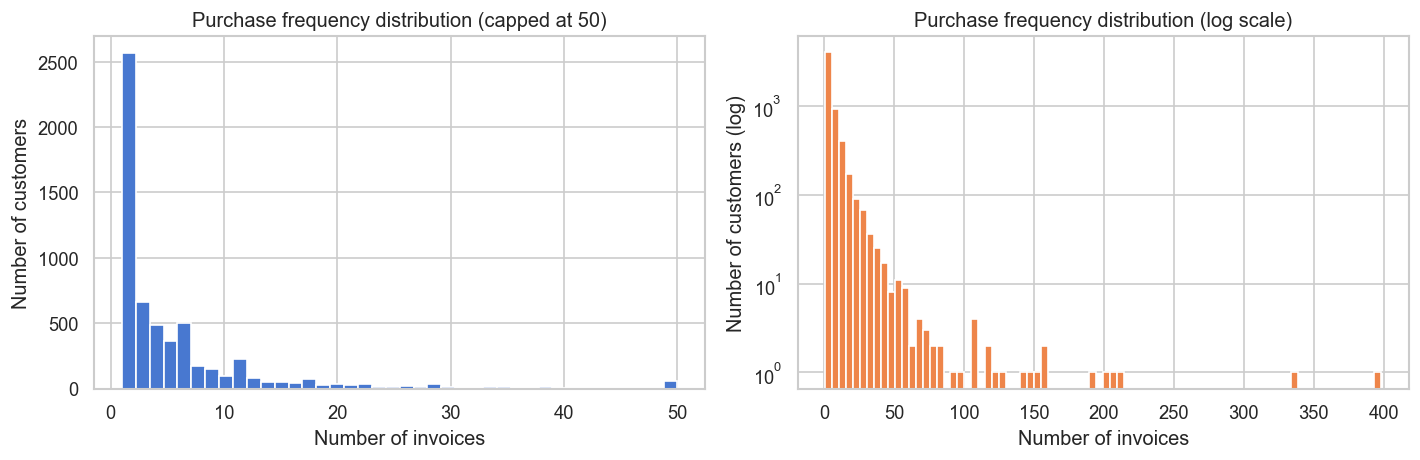

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution (capped at 50 for readability)
axes[0].hist(customer_freq['num_invoices'].clip(upper=50), bins=40,
             color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Purchase frequency distribution (capped at 50)')
axes[0].set_xlabel('Number of invoices')
axes[0].set_ylabel('Number of customers')

# Log scale for long tail
axes[1].hist(customer_freq['num_invoices'], bins=80,
             color=sns.color_palette('muted')[1], edgecolor='white', log=True)
axes[1].set_title('Purchase frequency distribution (log scale)')
axes[1].set_xlabel('Number of invoices')
axes[1].set_ylabel('Number of customers (log)')

plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_customer_frequency.png', bbox_inches='tight')
plt.show()

## 10. Geographic Distribution

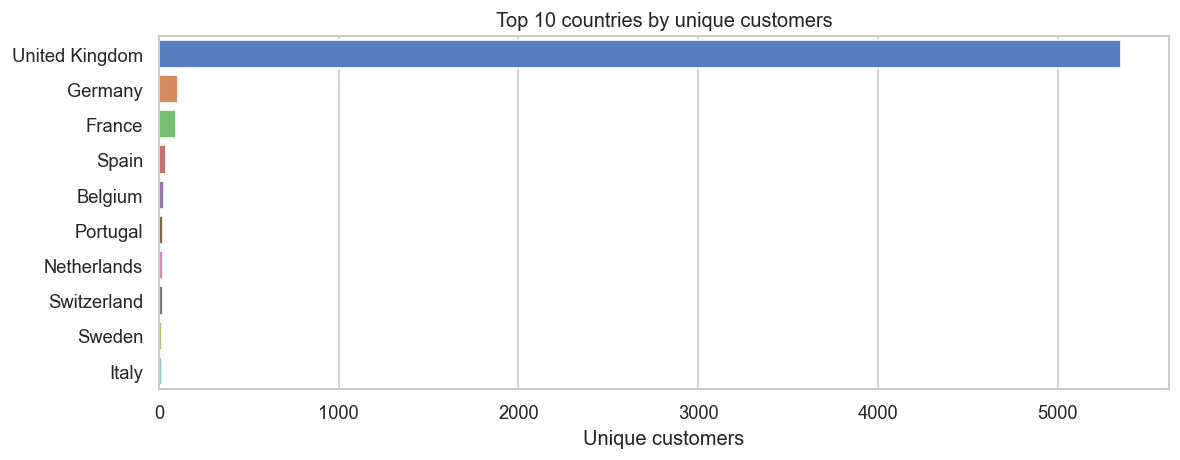


Note: UK dominates — consistent with a UK-based wholesaler.


In [18]:
top_countries = (
    df_clean
    .groupby('country')['customer_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'customer_id': 'unique_customers'})
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=top_countries, x='unique_customers', y='country', ax=ax,
            palette='muted')
ax.set_title('Top 10 countries by unique customers')
ax.set_xlabel('Unique customers')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_top_countries.png', bbox_inches='tight')
plt.show()

print("\nNote: UK dominates — consistent with a UK-based wholesaler.")

## 11. Inter-Purchase Time Distribution

The distribution of days between consecutive purchases informs whether
BG/NBD's Poisson transaction assumption is reasonable for this dataset.

Inter-purchase time summary (days):
count   765826.00
mean         2.08
std         18.31
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        714.00
Name: invoice_date, dtype: float64


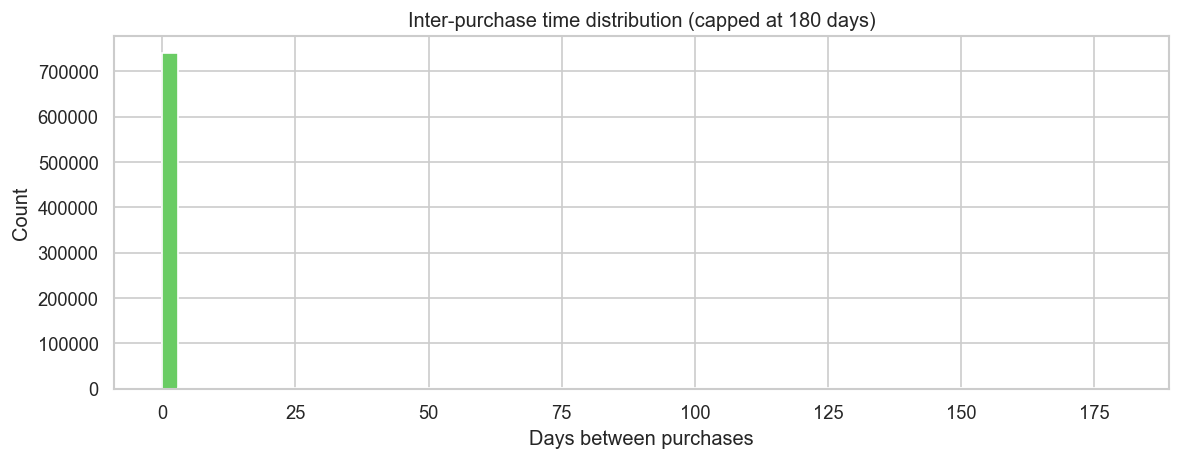

In [19]:
# Compute inter-purchase times for repeat customers only
repeat_customers = customer_freq[customer_freq['num_invoices'] >= 2]['customer_id']

ipt = (
    df_clean[df_clean['customer_id'].isin(repeat_customers)]
    .groupby('customer_id')['invoice_date']
    .apply(lambda x: x.sort_values().diff().dt.days.dropna().tolist())
    .explode()
    .astype(float)
    .dropna()
)

print(f"Inter-purchase time summary (days):")
print(ipt.describe().round(2))

fig, ax = plt.subplots()
ax.hist(ipt.clip(upper=180), bins=60, color=sns.color_palette('muted')[2], edgecolor='white')
ax.set_title('Inter-purchase time distribution (capped at 180 days)')
ax.set_xlabel('Days between purchases')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_interpurchase_time.png', bbox_inches='tight')
plt.show()

## 12. Key Observations & Next Steps

### Observations

| # | Finding | Implication |
|---|---------|-------------|
| 1 | ~25% of rows have no `customer_id` | Drop before RFM — guest transactions are untrackable |
| 2 | ~1.8% of invoices are cancellations | Must exclude before computing frequency |
| 3 | ~27.6% of customers made only 1 purchase | BG/NBD can handle this; remaining 72.4% are repeat buyers which is a strong signal for model estimation |
| 4 | UK accounts for the majority of customers | Consider UK-only subset for cleaner modeling |
| 5 | Strong seasonality visible (Nov–Dec peaks) | Relevant context for BG/NBD stationarity assumption |

### Next Steps

Proceed to `02_rfm_computation.ipynb` to:
- Apply full cleaning pipeline via `src/preprocessing.py`
- Define observation and prediction windows
- Compute RFM metrics per customer
- Split into calibration and holdout periods